In [ ]:
import heapq

# Graph represented as adjacency list
graph = {
    'Sahiwal': [('Tarbella', 10), ('Haveli Lakha', 12)],
    'Tarbella': [('Sahiwal', 10), ('Haripur', 15)],
    'Haripur': [('Tarbella', 15), ('Quetta', 20)],
    'Haveli Lakha': [('Sahiwal', 12), ('Quetta', 15)],
    'Quetta': [('Haripur', 20), ('Haveli Lakha', 15)]
}

def dijkstra(graph, start, end):
    # Priority queue for (cost, node)
    queue = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if current_node == end:
            break

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    # Reconstruct shortest path
    path = []
    current = end
    while current:
        path.insert(0, current)
        current = previous[current]

    return path, distances[end]

# Example usage
start_node = 'Sahiwal'
end_node = 'Quetta'

shortest_path, total_cost = dijkstra(graph, start_node, end_node)
print("Shortest path:", " → ".join(shortest_path))
print("Total cost:", total_cost)


Shortest path: Sahiwal → Haveli Lakha → Quetta
Total cost: 27


Shortest path: Sahiwal → Haveli Lakha → Quetta
Total cost: 27


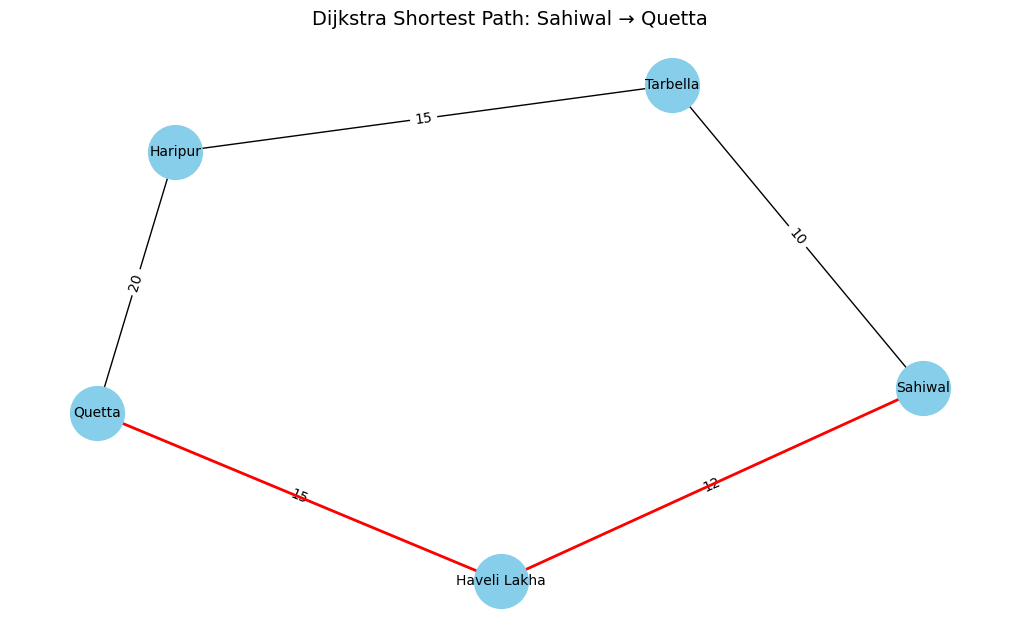

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed or undirected graph
G = nx.Graph()

# Add edges with weights
edges = [
    ('Sahiwal', 'Tarbella', 10),
    ('Sahiwal', 'Haveli Lakha', 12),
    ('Tarbella', 'Haripur', 15),
    ('Haripur', 'Quetta', 20),
    ('Haveli Lakha', 'Quetta', 15)
]

G.add_weighted_edges_from(edges)

# Run Dijkstra's algorithm
start = 'Sahiwal'
end = 'Quetta'
shortest_path = nx.dijkstra_path(G, start, end)
path_length = nx.dijkstra_path_length(G, start, end)

# Print path and cost
print("Shortest path:", " → ".join(shortest_path))
print("Total cost:", path_length)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # For consistent layout
plt.figure(figsize=(10, 6))

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)})

# Highlight the shortest path
path_edges = list(zip(shortest_path, shortest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

# Title
plt.title("Dijkstra Shortest Path: Sahiwal → Quetta", fontsize=14)
plt.show()


Shortest Path: Sahiwal → Haripur → Quetta
Total Cost: 23


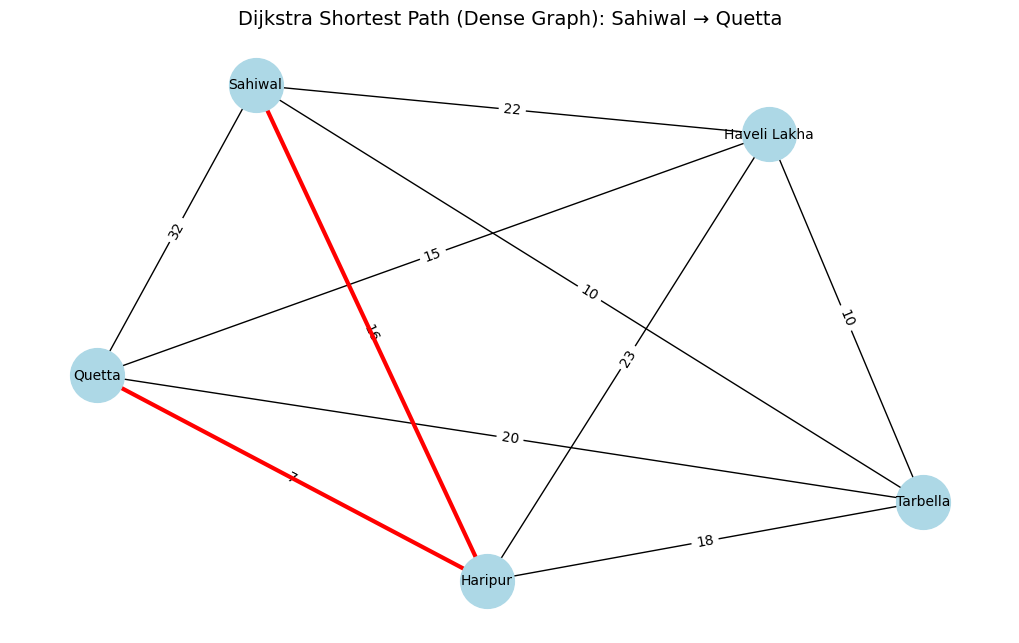

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the graph
G = nx.Graph()

# Add weighted edges (from dense graph)
edges = [
    ('Sahiwal', 'Tarbella', 10),
    ('Sahiwal', 'Haveli Lakha', 22),
    ('Sahiwal', 'Haripur', 16),
    ('Sahiwal', 'Quetta', 32),
    ('Tarbella', 'Haveli Lakha', 10),
    ('Tarbella', 'Haripur', 18),
    ('Tarbella', 'Quetta', 20),
    ('Haveli Lakha', 'Haripur', 23),
    ('Haveli Lakha', 'Quetta', 15),
    ('Haripur', 'Quetta', 7)
]

G.add_weighted_edges_from(edges)

# Dijkstra's Algorithm
start = 'Sahiwal'
end = 'Quetta'
shortest_path = nx.dijkstra_path(G, start, end)
path_cost = nx.dijkstra_path_length(G, start, end)

# Print shortest path info
print("Shortest Path:", " → ".join(shortest_path))
print("Total Cost:", path_cost)

# Visualization
pos = nx.spring_layout(G, seed=7)  # fixed layout
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)})

# Highlight shortest path
path_edges = list(zip(shortest_path, shortest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

# Title
plt.title("Dijkstra Shortest Path (Dense Graph): Sahiwal → Quetta", fontsize=14)
plt.show()
